# 02 — Closure modelling: from two scales to one

The averaging principle says that when `eps << 1` the fast variables equilibrate so quickly,
relative to the slow ones, that their contribution to the slow equation can be replaced by its
average under the fast invariant measure with the slow state held frozen:

$$\dot x_k = -x_{k-1}(x_{k-2} - x_{k+1}) - x_k + F + h_x\,\bar y_k
\qquad\longrightarrow\qquad
\dot x_k = -x_{k-1}(x_{k-2} - x_{k+1}) - x_k + F + h_x\,m(x_k)$$

`m` is not available in closed form; it is **fitted to data** (Calvello, Reich & Stuart 2025,
Appendix B.2 — by Gaussian process regression).

This notebook does three things:

1. Fits `m` three ways and compares them.
2. **Quantifies what the approximation discards** — the part of `\bar y_k` that is not a function
   of `x_k` at all. This number bounds what any memoryless closure can achieve, and is the gap
   PR-4 tries to close.
3. Checks that the resulting single-scale model reproduces the right slow-variable *climate*, and
   measures its Lyapunov time — the yardstick for every forecast horizon later.

In [1]:
%load_ext autoreload
%autoreload 2

import warnings
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np

warnings.filterwarnings("ignore")
plt.rcParams.update({"figure.dpi": 110, "axes.grid": True, "grid.alpha": 0.25, "font.size": 9})

from msdyn.closures import ClosurePairs, GaussianProcessClosure, LinearClosure, PolynomialClosure, gather_closure_pairs
from msdyn.data import load_dataset
from msdyn.diagnostics import lyapunov_time, max_lyapunov_exponent, power_spectrum
from msdyn.systems.l96 import L96Params, L96SingleScale

DATA = Path.cwd().parent / "data"
multiscale = load_dataset(DATA / "l96_multiscale_eps0.0078125.npz")
print(multiscale.describe())

multiscale | 32 x 3990 x 81 | dt=0.0150391 | T=59.9908 | K=9 J=8 F=10.0 h_x=-0.8 h_y=1.0 eps=0.0078125


## 1. The `(x_k, ybar_k)` scatter

Pool pairs over time **and** over ring position `k`. Pooling over `k` is legitimate because the
system is cyclically symmetric — and it is what makes `m` a single scalar function rather than
`K` separate ones.

In [2]:
pairs = ClosurePairs(
    np.concatenate([gather_closure_pairs(multiscale.trajectories[i], multiscale.params).x
                    for i in range(multiscale.n_trajectories)]),
    np.concatenate([gather_closure_pairs(multiscale.trajectories[i], multiscale.params).ybar
                    for i in range(multiscale.n_trajectories)]),
)
print(f"{len(pairs):,} pooled pairs")

gp = GaussianProcessClosure(max_pairs=800, seed=0).fit(pairs)
poly = PolynomialClosure(degree=3).fit(pairs)
linear = PolynomialClosure(degree=1).fit(pairs)
g0 = LinearClosure(slope=multiscale.params.h_y)   # the analytic 'G0' predictor, unfitted

print(gp)
print(poly)

1,149,120 pooled pairs


GaussianProcessClosure(max_pairs=800, kernel=2.05**2 * RBF(length_scale=6.15))
PolynomialClosure(m(x) = +0.1872x^0 + +0.4018x^1 + +0.004156x^2 + -0.001677x^3, residual_std=0.6268)


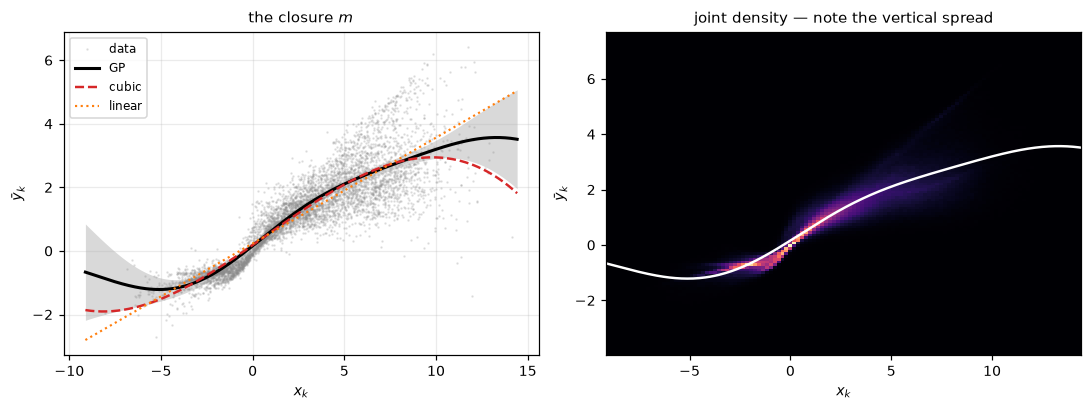

In [3]:
grid = np.linspace(pairs.x.min(), pairs.x.max(), 400)
gp_mean, gp_std = gp.predict_with_std(grid)

fig, axes = plt.subplots(1, 2, figsize=(10, 3.8))

ax = axes[0]
ax.plot(pairs.x[::200], pairs.ybar[::200], ".", ms=1.2, alpha=0.25, color="0.55", label="data")
ax.plot(grid, gp_mean, color="k", lw=2, label="GP")
ax.fill_between(grid, gp_mean - 2 * gp_std, gp_mean + 2 * gp_std, color="k", alpha=0.15, lw=0)
ax.plot(grid, poly(grid), color="tab:red", lw=1.6, ls="--", label="cubic")
ax.plot(grid, linear(grid), color="tab:orange", lw=1.4, ls=":", label="linear")
ax.set_xlabel("$x_k$"); ax.set_ylabel("$\\bar y_k$")
ax.set_title("the closure $m$", fontsize=10); ax.legend(fontsize=8)

ax = axes[1]
ax.hist2d(pairs.x, pairs.ybar, bins=(120, 120), cmap="magma", density=True)
ax.plot(grid, gp_mean, color="w", lw=1.6)
ax.set_xlabel("$x_k$"); ax.set_ylabel("$\\bar y_k$")
ax.set_title("joint density — note the vertical spread", fontsize=10); ax.grid(False)
fig.tight_layout()

## 2. What the memoryless approximation throws away

The scatter is **thick**. `m(x_k)` is a conditional mean, and the vertical spread around it is the
part of the fast forcing that is not a function of the local slow variable — it depends on the
neighbours, and on the *history*.

Mori–Zwanzig says the exact closure is non-Markovian. The number below is how much of `ybar` a
memoryless closure cannot reach, and it is the target of PR-4 (`docs/PLAN.md`).

std(ybar)              = 1.385
std(residual)          = 0.627
variance explained     = 79.5%
unexplained (memory + neighbours) = 20.5%


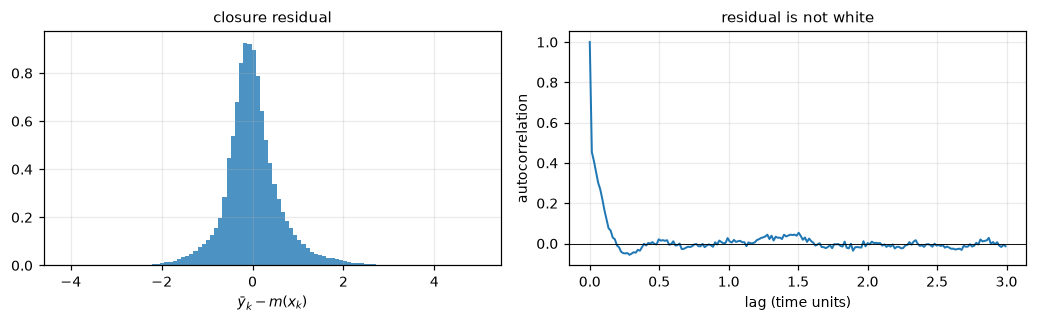

In [4]:
residual = pairs.ybar - poly(pairs.x)
explained = 1 - residual.var() / pairs.ybar.var()

print(f"std(ybar)              = {pairs.ybar.std():.3f}")
print(f"std(residual)          = {residual.std():.3f}")
print(f"variance explained     = {100 * explained:.1f}%")
print(f"unexplained (memory + neighbours) = {100 * (1 - explained):.1f}%")

fig, axes = plt.subplots(1, 2, figsize=(9.5, 3))
axes[0].hist(residual, bins=100, density=True, color="tab:blue", alpha=0.8)
axes[0].set_xlabel("$\\bar y_k - m(x_k)$"); axes[0].set_title("closure residual", fontsize=10)

# Residual autocorrelation: if it were white, a simple stochastic parameterisation would
# suffice. Structure here is evidence that *memory*, not just noise, is missing.
series = multiscale.fast_average()[0, :, 0] - poly(multiscale.slow[0, :, 0])
series = series - series.mean()
acf = np.correlate(series, series, mode="full")[len(series) - 1:]
acf = acf / acf[0]
lags = np.arange(len(acf)) * multiscale.dt
axes[1].plot(lags[:200], acf[:200], lw=1.3)
axes[1].axhline(0, color="k", lw=0.6)
axes[1].set_xlabel("lag (time units)"); axes[1].set_ylabel("autocorrelation")
axes[1].set_title("residual is not white", fontsize=10)
fig.tight_layout()

## 3. Does the single-scale model reproduce the right climate?

Pointwise agreement is impossible — these are different chaotic systems. The right test is
*distributional*: does the reduced model visit the same region of state space, with the same
frequencies?

singlescale | 32 x 4001 x 9 | dt=0.015 | T=60 | K=9 J=8 F=10.0 h_x=-0.8 h_y=1.0 eps=0.0078125


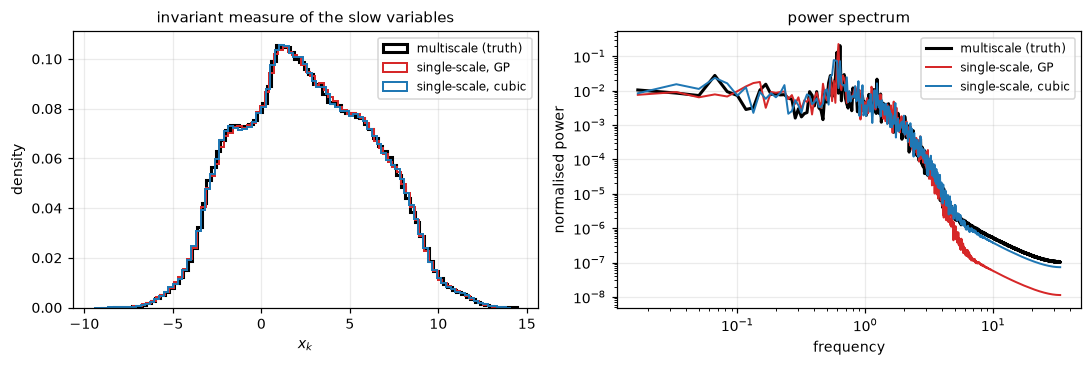

In [5]:
single_gp = load_dataset(DATA / "l96_singlescale_gp.npz")
single_poly = load_dataset(DATA / "l96_singlescale_poly3.npz")
print(single_gp.describe())

fig, axes = plt.subplots(1, 2, figsize=(10, 3.4))
runs = [
    ("multiscale (truth)", multiscale.slow, multiscale.dt, "k", 2.0),
    ("single-scale, GP", single_gp.trajectories, single_gp.dt, "tab:red", 1.3),
    ("single-scale, cubic", single_poly.trajectories, single_poly.dt, "tab:blue", 1.3),
]
for label, traj, dt, color, lw in runs:
    axes[0].hist(traj.reshape(-1), bins=90, density=True, histtype="step", lw=lw, color=color, label=label)
    freqs, spectrum = power_spectrum(traj[0], dt)
    axes[1].loglog(freqs, spectrum / spectrum.sum(), lw=lw, color=color, label=label)

axes[0].set_xlabel("$x_k$"); axes[0].set_ylabel("density")
axes[0].set_title("invariant measure of the slow variables", fontsize=10); axes[0].legend(fontsize=8)
axes[1].set_xlabel("frequency"); axes[1].set_ylabel("normalised power")
axes[1].set_title("power spectrum", fontsize=10); axes[1].legend(fontsize=8)
fig.tight_layout()

In [6]:
from msdyn.evaluation.metrics import invariant_measure_kl

truth = multiscale.slow
print("KL( single-scale || multiscale ) for the slow-variable marginal:")
for label, traj in [("GP closure", single_gp.trajectories), ("cubic closure", single_poly.trajectories)]:
    print(f"  {label:16s} {invariant_measure_kl(traj, truth):.4f}")
print("\n(lower is better; 0 would mean the reduced model has exactly the right climate)")

KL( single-scale || multiscale ) for the slow-variable marginal:
  GP closure       0.0004
  cubic closure    0.0002

(lower is better; 0 would mean the reduced model has exactly the right climate)


## 4. The slow Lyapunov time

This is the number that makes forecast horizons interpretable. The multiscale system's maximal
exponent (~53) belongs to the fast ring; the single-scale model's exponent is the rate at which
*slow-variable* predictability is actually lost.

lambda_max (single-scale) = 1.002
slow Lyapunov time        = 0.998 time units
                          = 66 samples at sample_dt = 0.0150

So PANDA's native 128-step horizon covers 1.93 slow Lyapunov times,
and its 512-step context covers 7.72.


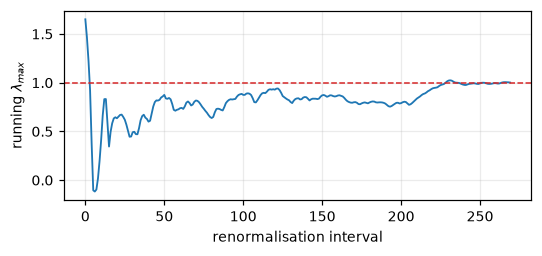

In [7]:
params = L96Params()
reduced = L96SingleScale(params, poly)
exponent, running = max_lyapunov_exponent(
    reduced, single_poly.trajectories[0, -1], dt=1e-3, t_renorm=0.1, n_renorm=300, n_discard=30
)
slow_lyapunov_time = lyapunov_time(exponent)
print(f"lambda_max (single-scale) = {exponent:.3f}")
print(f"slow Lyapunov time        = {slow_lyapunov_time:.3f} time units")
print(f"                          = {slow_lyapunov_time / multiscale.dt:.0f} samples at sample_dt = {multiscale.dt:.4f}")
print(f"\nSo PANDA's native 128-step horizon covers "
      f"{128 * multiscale.dt / slow_lyapunov_time:.2f} slow Lyapunov times,")
print(f"and its 512-step context covers {512 * multiscale.dt / slow_lyapunov_time:.2f}.")

fig, ax = plt.subplots(figsize=(5, 2.4))
ax.plot(running, lw=1.2); ax.axhline(exponent, color="tab:red", ls="--", lw=1)
ax.set_xlabel("renormalisation interval"); ax.set_ylabel("running $\\lambda_{max}$")
fig.tight_layout()

---

**Next:** `03_panda_zeroshot.ipynb` puts PANDA on this data — first validating the adapter against
a system from PANDA's own held-out set, then forecasting the single-scale and multiscale slow
variables against every baseline.